Name: **Stephane Chambrelain Talla Fotsing**  
Student Number: **ST139766**  
Program: **Data Analytics and Artificial Intelligence**  
Course - **Introduction to Artificial Intelligence**  
**Assignment 9: Unsupervised Learning**

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 1. Dataset Selection and Preprocessing

**- Load and read the Wine dataset**

In [23]:

columns = [
    "Class", "Alcohol", "Malic_Acid", "Ash", "Alcalinity_of_Ash",
    "Magnesium", "Total_Phenols", "Flavanoids", "Nonflavanoid_Phenols",
    "Proanthocyanins", "Color_Intensity", "Hue",
    "OD280_OD315", "Proline"
]
# Read the data and add column names
df = pd.read_csv("/content/wine.data", header=None, names=columns)
# Save as CSV without an extra index column
df.to_csv("/content/wine.csv", index=False)

df.head()

,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


**- Check missing values**

In [24]:
# Count missing values in each column
df.isnull().sum()

,0
Class,0
Alcohol,0
Malic_Acid,0
Ash,0
Alcalinity_of_Ash,0
Magnesium,0
Total_Phenols,0
Flavanoids,0
Nonflavanoid_Phenols,0
Proanthocyanins,0


**- Separate features and class labels**

In [25]:
# Keep class labels for comparison after clustering
class_labels = df["Class"].copy()
# Use only the numerical measurements for clustering and PCA
X = df.drop(columns="Class")

**- Handle missing values and standardize**

In [26]:
# Replace any missing feature values with column medians
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

In [27]:
# Standardize each feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [28]:
# Preview the standardized features
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

X_scaled_df.head()

,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


## 2. Clustering

**- Compare different numbers of clusters**

In [29]:
cluster_range = range(2, 11)

inertia = []
kmeans_scores = []
hierarchical_scores = []

for k in cluster_range:
    # K-means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    kmeans_scores.append(silhouette_score(X_scaled, kmeans_labels))

    # Hierarchical clustering using Ward linkage
    hierarchical = AgglomerativeClustering(n_clusters=k, linkage="ward")
    hierarchical_labels = hierarchical.fit_predict(X_scaled)
    hierarchical_scores.append(silhouette_score(X_scaled, hierarchical_labels))

**- Elbow curve and silhouette scores**

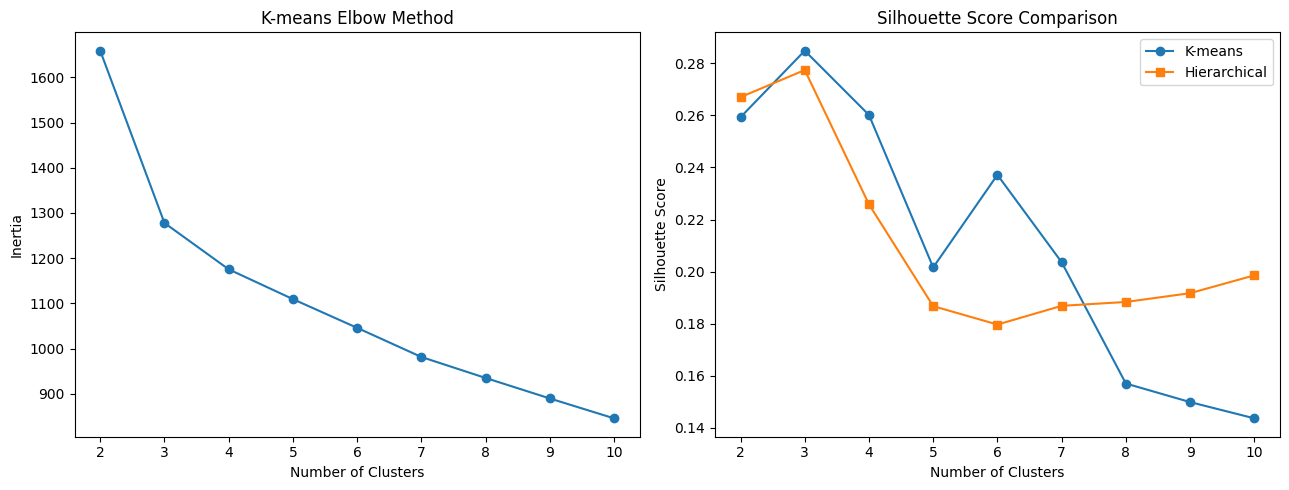

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow method for K-means
axes[0].plot(cluster_range, inertia, marker="o")
axes[0].set_title("K-means Elbow Method")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(cluster_range))

# Silhouette scores for both methods
axes[1].plot(cluster_range, kmeans_scores, marker="o", label="K-means")
axes[1].plot(cluster_range, hierarchical_scores, marker="s", label="Hierarchical")
axes[1].set_title("Silhouette Score Comparison")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(cluster_range))
axes[1].legend()

plt.tight_layout()
plt.show()

**- Select cluster counts and fit the final models**

In [31]:
# Select the cluster count with the highest silhouette score
best_kmeans_k = list(cluster_range)[kmeans_scores.index(max(kmeans_scores))]
best_hierarchical_k = list(cluster_range)[hierarchical_scores.index(max(hierarchical_scores))]

In [32]:
# Fit final models
kmeans = KMeans(n_clusters=best_kmeans_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
hierarchical = AgglomerativeClustering(n_clusters=best_hierarchical_k, linkage="ward")
hierarchical_labels = hierarchical.fit_predict(X_scaled)

In [33]:
# Display results
clustering_results = pd.DataFrame({
    "Method": ["K-means", "Hierarchical"],
    "Selected Clusters": [best_kmeans_k, best_hierarchical_k],
    "Silhouette Score": [silhouette_score(X_scaled, kmeans_labels),silhouette_score(X_scaled, hierarchical_labels)]
})
clustering_results.round(4)

,Method,Selected Clusters,Silhouette Score
0,K-means,3,0.2849
1,Hierarchical,3,0.2774


**- Visualize the clusters**

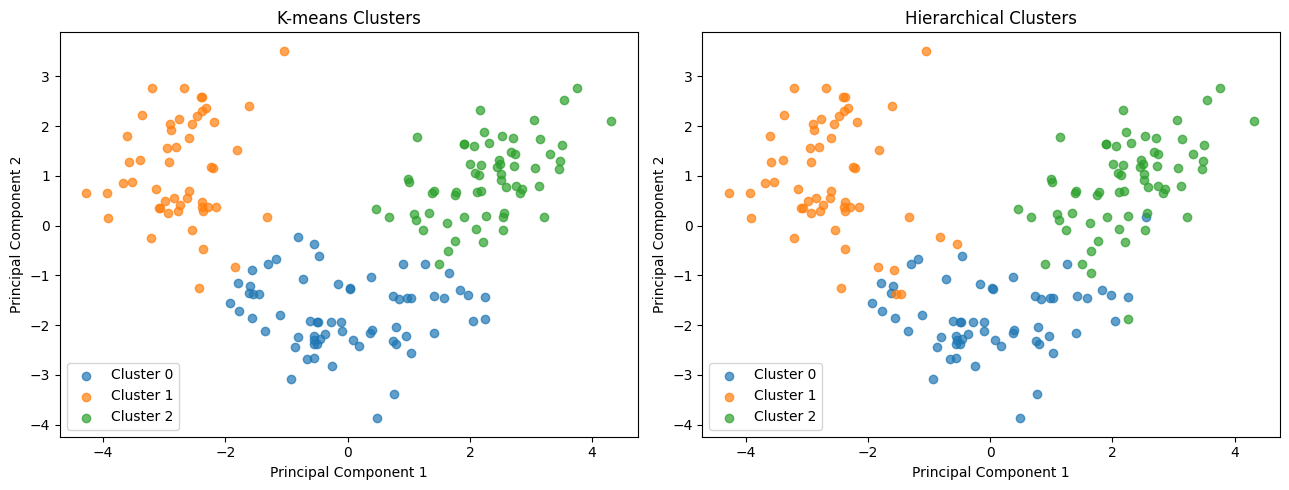

In [34]:
# Reduce to two dimensions for visualization
pca_visual = PCA(n_components=2)
X_pca_visual = pca_visual.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_results = [("K-means", kmeans_labels), ("Hierarchical", hierarchical_labels)]

for ax, (name, labels) in zip(axes, plot_results):
    for cluster in sorted(set(labels)):
        mask = labels == cluster
        ax.scatter(X_pca_visual[mask, 0], X_pca_visual[mask, 1], label=f"Cluster {cluster}", alpha=0.7)
    # Title, label and legend
    ax.set_title(f"{name} Clusters")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Dimensionality Reduction

**- Display the explained variance**

In [35]:
# Percentage of variance captured by each component
explained_variance = pca_visual.explained_variance_ratio_ * 100
print(f"PC1 explained variance: {explained_variance[0]:.2f}%")
print(f"PC2 explained variance: {explained_variance[1]:.2f}%")
print(f"Total explained variance: {explained_variance.sum():.2f}%")

PC1 explained variance: 36.20%
PC2 explained variance: 19.21%
Total explained variance: 55.41%


**- Visualize the data in two dimensions**

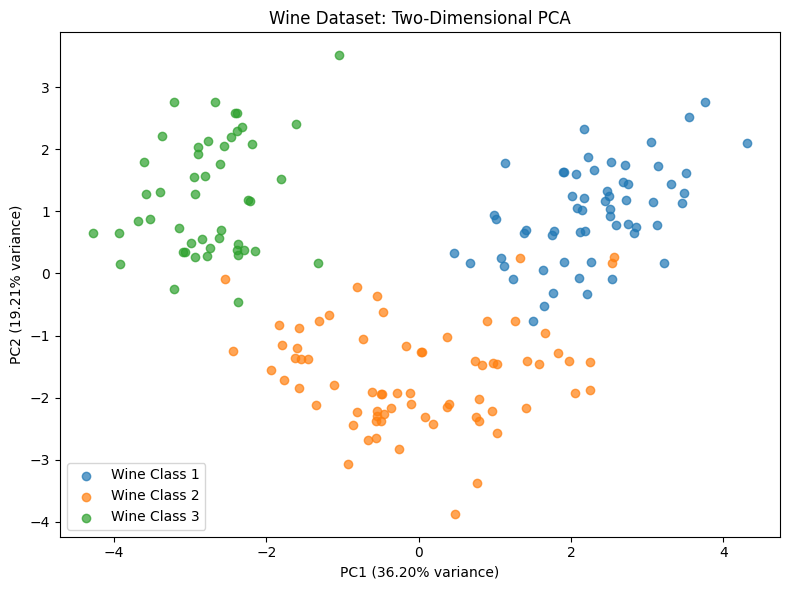

In [36]:
plt.figure(figsize=(8, 6))

for wine_class in sorted(class_labels.unique()):
    mask = (class_labels == wine_class).to_numpy()
    plt.scatter(X_pca_visual[mask, 0], X_pca_visual[mask, 1], label=f"Wine Class {wine_class}", alpha=0.7)
# Title, labels and legend
plt.xlabel(f"PC1 ({explained_variance[0]:.2f}% variance)")
plt.ylabel(f"PC2 ({explained_variance[1]:.2f}% variance)")
plt.title("Wine Dataset: Two-Dimensional PCA")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Model Evaluation

In [37]:
# Evaluation of the model using Silhouette score
evaluation = pd.DataFrame({
    "Model": ["K-means", "Hierarchical"],
    "Silhouette Score": [silhouette_score(X_scaled, kmeans_labels), silhouette_score(X_scaled, hierarchical_labels)]
    })

evaluation.round(4)

,Model,Silhouette Score
0,K-means,0.2849
1,Hierarchical,0.2774


### Interpretation

The silhouette score measures how well observations fit within their clusters, with higher scores indicating better separation. K-means scored 0.2849, slightly higher than Hierarchical clustering at 0.2774. Both scores suggest some overlap between clusters, but K-means performed slightly better based on this metric.

## 5. Deployment and Monitoring

**- Hypothetical scenario**

A winery could use the K-means model to group new wines based on their chemical properties. New measurements would pass through the saved imputer and scaler before being assigned to the nearest cluster.

**- Deployment challenges**

Missing or incorrect measurements could affect results. Large volumes of requests could increase response times, requiring batch processing or additional computing resources. Changes in wine characteristics could also make the model less useful over time.

**- Monitoring and updating**

Monitor response times, input quality, cluster sizes, and distances to cluster centres. Evaluate silhouette scores on suitable new batches. Retrain and validate the model with representative new data when performance declines, keeping the previous version available for rollback.

In [39]:
!ls -la "/content/drive/MyDrive"

total 545
drwx------ 5 root root   4096 Sep 13 18:37  .
drwx------ 5 root root   4096 Sep 13 18:37  ..
-rw------- 1 root root    175 Nov 27  2021 'Altyd gefokus - Midterm Exam-Online.gdoc'
-rw------- 1 root root     48 Jan 17  2020  BackupRestoreTest.txt
drwx------ 2 root root   4096 May  3  2021  Classroom
-rw------- 1 root root    175 Oct  3  2024 'Client Intake Form - Fillable - 2024.gdoc'
-rw------- 1 root root 531006 Sep 30  2024 'Client Intake Form - Fillable - 2024.pdf'
drwx------ 2 root root   4096 May  1 12:32 'Colab Notebooks'
-rw------- 1 root root   3815 May 26 15:49  employees.csv
drwx------ 2 root root   4096 Feb 26  2021  Takeout


In [40]:
!find "/content/drive/MyDrive/Colab Notebooks" -iname "Assignment_9*.ipynb"

/content/drive/MyDrive/Colab Notebooks/Assignment_9.ipynb


In [41]:
from getpass import getpass
github_token = getpass("Enter your GitHub PAT: ")

Enter your GitHub PAT: ··········


In [43]:
!git clone https://github.com/StephaneTF/colab-git-assignment2-ST.git /content/colab-git-assignment2-ST

Cloning into '/content/colab-git-assignment2-ST'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 26 (delta 10), reused 11 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 485.52 KiB | 12.45 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [44]:
!ls -la /content/colab-git-assignment2-ST

total 660
drwxr-xr-x 4 root root   4096 Sep 13 18:47  .
drwxr-xr-x 1 root root   4096 Sep 13 18:47  ..
-rw-r--r-- 1 root root   5415 Sep 13 18:47  assignment2.ipynb
drwxr-xr-x 8 root root   4096 Sep 13 18:47  .git
drwxr-xr-x 2 root root   4096 Sep 13 18:47  Lesson_10_assignment
-rw-r--r-- 1 root root  12704 Sep 13 18:47  Lesson_3_assignment.ipynb
-rw-r--r-- 1 root root  80271 Sep 13 18:47 'Lesson 4 assignment.ipynb'
-rw-r--r-- 1 root root 549515 Sep 13 18:47  Lesson_5_Assignment.ipynb
